In [ ]:
# pyenv activate nitrates

In [60]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os

## Registro Ramblas Mar Menor

In [61]:
filename = "Registro_Ramblas_MARMENOR.xlsx"

In [62]:
# Cargamos las hojas que nos interesan del xlsx

df_caudal = pd.read_excel(filename, sheet_name="Caudal", skiprows=6, usecols=range(1,26)).dropna(how="all")
df_nitratos = pd.read_excel(filename, sheet_name="Nitratos", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_fosfatos = pd.read_excel(filename, sheet_name="Fosfatos", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_conductividad = pd.read_excel(filename, sheet_name="Conductividad", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_nitratosdiario = pd.read_excel(filename, sheet_name="NitratosDiario", skiprows=6, usecols=range(1,14)).dropna(how="all")
df_fosfatosdiario = pd.read_excel(filename, sheet_name="FosfatosDiario", skiprows=6, usecols=range(1,14)).dropna(how="all")

# Lista de DataFrames
dataframes = [df_caudal, df_nitratos, df_fosfatos, df_conductividad, df_nitratosdiario, df_fosfatosdiario]

Los datos de NitratiosDiario y FosfatosDiario parece que se han sacado simplemente haciendo el producto de los mg/L * l/s * 86400 s/día (nitratos * caudal). Esto no va a dar mucha información puesto que se asumen que tanto la medida puntual de nitratos como la de caudal son constantes durante el día entero.

In [63]:
len(df_caudal.columns)

25

In [70]:
for i in range(len(dataframes)):
    # Extraemos la fecha más reciente en las instancias que tienen dos fechas
    dataframes[i]['Fecha'] = dataframes[i]['Fecha'].apply(extract_recent_date)
    # Quitamos las entradas que no tienen fecha
    dataframes[i] = dataframes[i][~dataframes[i]['Fecha'].isna()]
    # Ponemos como 0's todas las observaciones que no tienen un valor
    dataframes[i] = dataframes[i].fillna(0)
    # Ponemos como 0's todas los strings
    dataframes[i] = dataframes[i].applymap(replace_strings)


# Definir el umbral
threshold = 0.99
# Función para encontrar columnas con más del 95% de ceros en un DataFrame
def columns_with_high_zero_percentage(df, threshold):
    zero_percentage = (df == 0).mean()
    return set(zero_percentage[zero_percentage > threshold].index)
# Encontrar columnas con más del 90% de ceros en cada DataFrame
columns_sets = [columns_with_high_zero_percentage(df, threshold) for df in [df_caudal, df_nitratos, df_fosfatos, df_conductividad]] # La suma diaria de nitratos y fosfatos no se considera porque tiene menos columnas
# Encontrar la intersección de estas columnas en todos los DataFrames
common_columns = set.intersection(*columns_sets)

for i in range(len(dataframes)):
    dataframes[i].drop(columns=common_columns, inplace=True, errors="ignore")


cols_to_keep = ["Fecha", "Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia", "Desembocadura rambla de Miranda", "Desembocadura rambla del Miedo", "Desembocadura rambla de las Matildes", "Rambla de las Matildes - corriente sur", "Lo Poyo", "Lengua de Vaca", "Valla Militar", "Freático Los Alcázares", "Venta Simón"]

for i in range(len(dataframes)):
    # Para evitar que intente seleccionar columnas que no existen
    existing_cols = dataframes[i].columns.intersection(cols_to_keep)
    dataframes[i] = dataframes[i].loc[:, existing_cols] 


# Reasignar los DataFrames procesados a sus variables originales
df_caudal, df_nitratos, df_fosfatos, df_conductividad, df_nitratosdiario, df_fosfatosdiario = dataframes


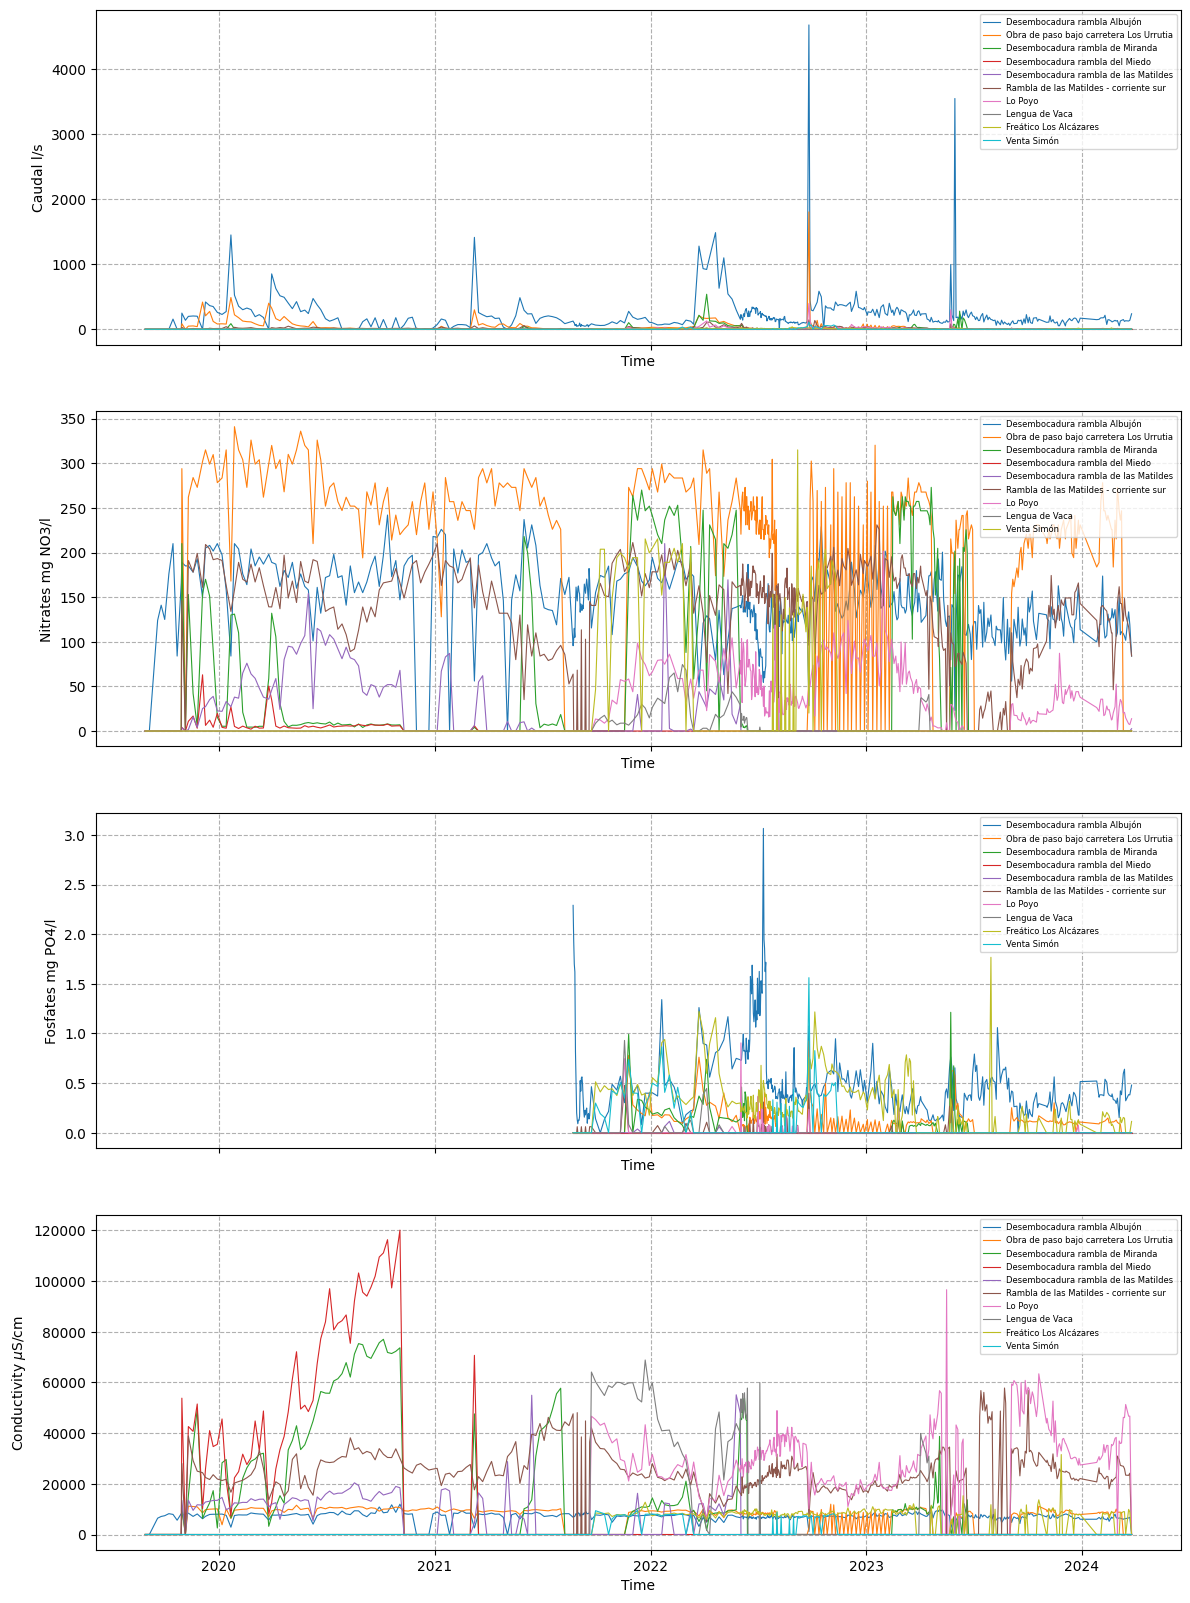

In [82]:
fig, ax = plt.subplots(figsize = (14,20), nrows=4, ncols=1, sharex = True)
for col in df_caudal.columns[1:]:
    ax[0].plot(df_caudal["Fecha"], df_caudal[col], label = f"{col}", linewidth=0.8)
ax[0].legend(loc="upper right", fontsize = 6)
ax[0].set_ylabel("Caudal l/s")
ax[0].set_xlabel("Time")
ax[0].grid(linestyle = '--')

for col in df_nitratos.columns[1:]:
    ax[1].plot(df_nitratos["Fecha"], df_nitratos[col], label = f"{col}", linewidth=0.8)
ax[1].legend(loc="upper right", fontsize = 6)
ax[1].set_ylabel("Nitrates mg NO3/l")
ax[1].set_xlabel("Time")
ax[1].grid(linestyle = '--')

for col in df_fosfatos.columns[1:]:
    ax[2].plot(df_fosfatos["Fecha"], df_fosfatos[col], label = f"{col}", linewidth=0.8)
ax[2].legend(loc="upper right", fontsize = 6)
ax[2].set_ylabel("Fosfates mg PO4/l")
ax[2].set_xlabel("Time")
ax[2].grid(linestyle = '--')

for col in df_conductividad.columns[1:]:
    ax[3].plot(df_conductividad["Fecha"], df_conductividad[col], label = f"{col}", linewidth=0.8)
ax[3].legend(loc="upper right", fontsize = 6)
ax[3].set_ylabel("Conductivity $\mu$S/cm")
ax[3].set_xlabel("Time")
ax[3].grid(linestyle = '--')

## SAIH - Ramblas

- Agrupar por localización o por variables??
- Para reducir la cantidad de datos, de los parámetros que están medidos a diferentes profundidates, ver si éstas son diferentes para quedarnos solamente con una si fuera posible. Por ejemplo, los datos de clorofila, temperatura o de oxígeno a varias profundidades parece que son muy similares

### Comparación entre caudal del Canal Mar Menor y SAIH

In [143]:
# Cargamos los datos
caudal = pd.read_parquet("Ramblas/06A18-Desemboc Rbla Albujon/06A18Q01-Caudal.parquet").set_index("Date")
# Ponemos la fecha, que está como índice, en formato datetime
caudal.index = pd.to_datetime(caudal.index, format="%Y-%m-%d %H:%M:%S")
# Ponemos el caudal como variable numérica y la pasamos de m³/s a l/s
caudal["Caudal"] = pd.to_numeric(caudal["Caudal"], errors="coerce")*1000 
# Remuestreo en días sacando el caudal medio
caudal = caudal.resample('D').mean()

In [136]:
pluviometro = pd.read_parquet("Ramblas/06A18-Desemboc Rbla Albujon/06A18P01-Pluviometro.parquet").set_index("Date")
pluviometro.index = pd.to_datetime(pluviometro.index, format="%Y-%m-%d %H:%M:%S")
pluviometro["Pluviometro"] = pd.to_numeric(pluviometro["Pluviometro"], errors="coerce")
pluviometro = pluviometro.resample('D').sum()

In [137]:
nivel = pd.read_parquet("Ramblas/06A18-Desemboc Rbla Albujon/06A18U12-Nivel.parquet").set_index("Date")
nivel.index = pd.to_datetime(nivel.index, format="%Y-%m-%d %H:%M:%S")
nivel["Nivel"] = pd.to_numeric(nivel["Nivel"], errors="coerce")
nivel = nivel.resample('D').mean()

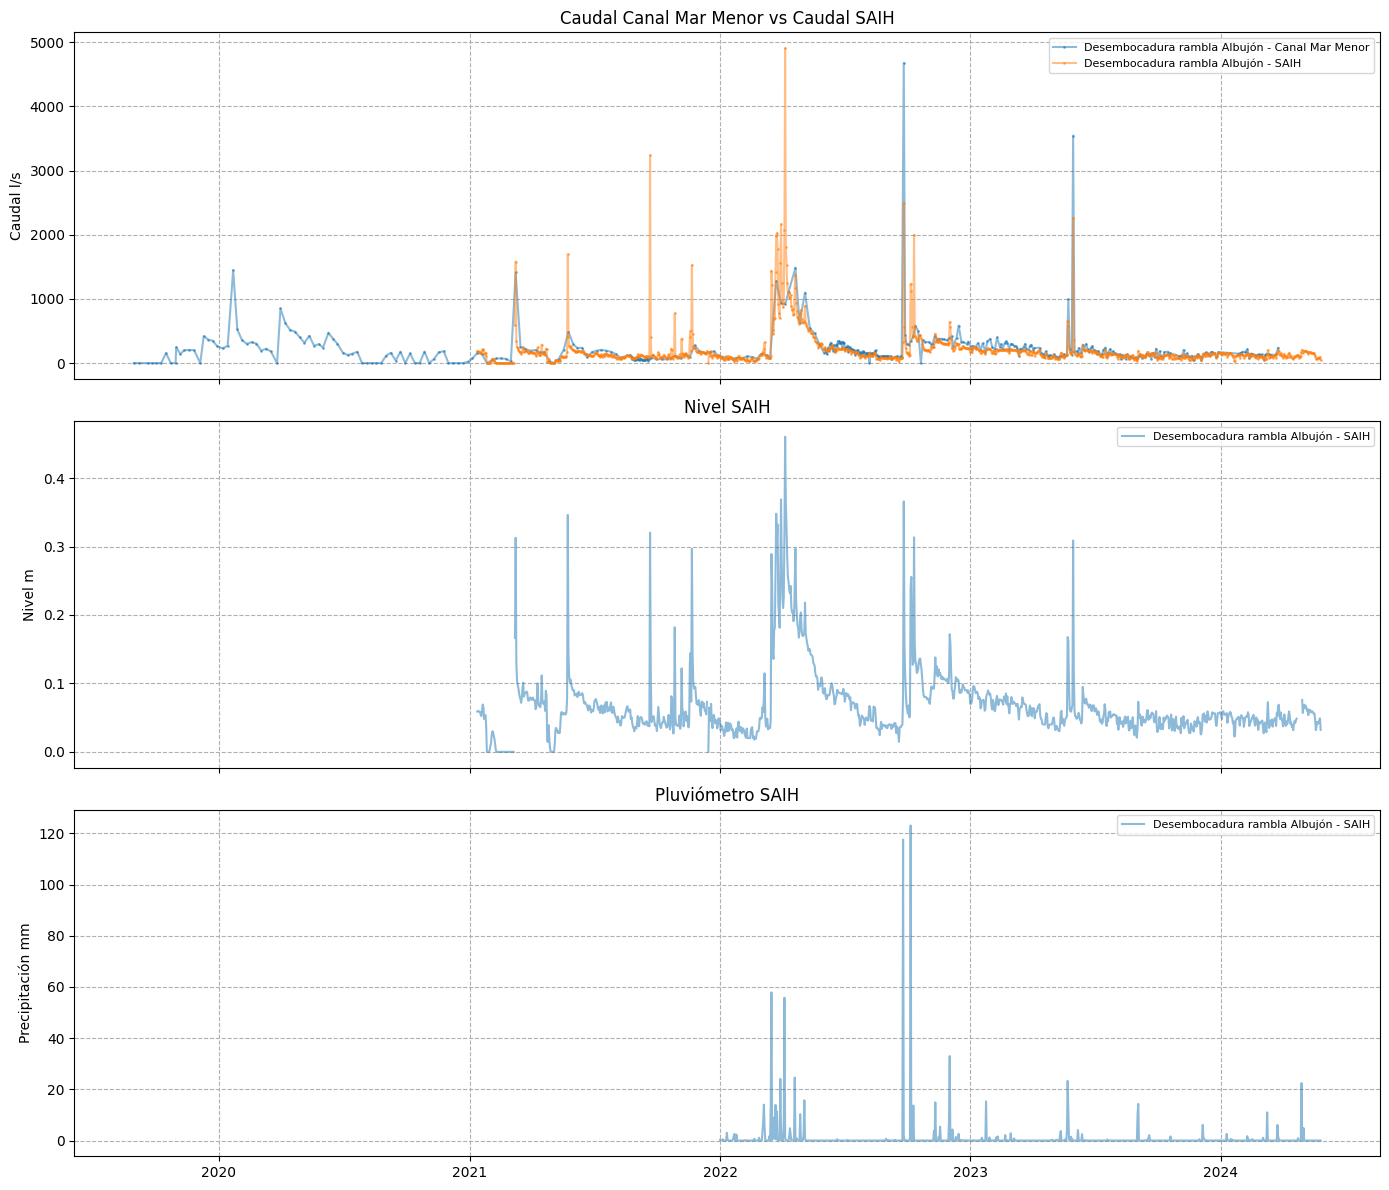

In [138]:
fig, ax = plt.subplots(figsize = (14,12), nrows=3, ncols=1, sharex=True)

ax[0].plot(df_caudal["Fecha"], df_caudal["Desembocadura rambla Albujón"], label = "Desembocadura rambla Albujón - Canal Mar Menor", alpha=0.5, marker = "o", markersize = 1)
ax[0].plot(caudal.index, caudal["Caudal"], label = "Desembocadura rambla Albujón - SAIH", alpha=0.5, marker = "o", markersize = 1)
ax[0].legend(loc="upper right", fontsize = 8)
ax[0].set_ylabel("Caudal l/s")
#ax[0].set_xlabel("Time")
ax[0].grid(linestyle = '--')
ax[0].set_title("Caudal Canal Mar Menor vs Caudal SAIH")

ax[1].plot(nivel.index, nivel["Nivel"], label = "Desembocadura rambla Albujón - SAIH", alpha=0.5)
ax[1].set_ylabel("Nivel m")
ax[1].set_title("Nivel SAIH")
ax[1].legend(loc="upper right", fontsize = 8)
ax[1].grid(linestyle = '--')

ax[2].plot(pluviometro.index, pluviometro["Pluviometro"], label = "Desembocadura rambla Albujón - SAIH", alpha=0.5)
ax[2].set_ylabel("Precipitación mm")
ax[2].set_title("Pluviómetro SAIH")
ax[2].legend(loc="upper right", fontsize = 8)
ax[2].grid(linestyle = '--')

fig.tight_layout()

Parece que el Nivel medido por el SAIH se corresponde con la medida de caudal del SAIH, pero por el contrario, el registro del pluviómetro, también del SAIH, se corresponde con los datos de Canal Mar Menor, ¿cuál nos creemos?

## Boyas UPCT

In [264]:
path = "boyaUPCT/extractedData/"
buoy = "CTD4"

In [265]:
archivos_csv = [f for f in os.listdir(path + buoy) if f.endswith('.csv')]
buoys = {}
# Leer cada archivo CSV y guardar el DataFrame en una variable con el mismo nombre que el archivo (sin la extensión)
for archivo in archivos_csv:
    nombre_variable = os.path.splitext(archivo)[0]
    #print(nombre_variable)
    ruta_completa = os.path.join(path + buoy, archivo)
    buoys[nombre_variable] = pd.read_csv(ruta_completa)
    globals()[nombre_variable] = pd.read_csv(ruta_completa)

    

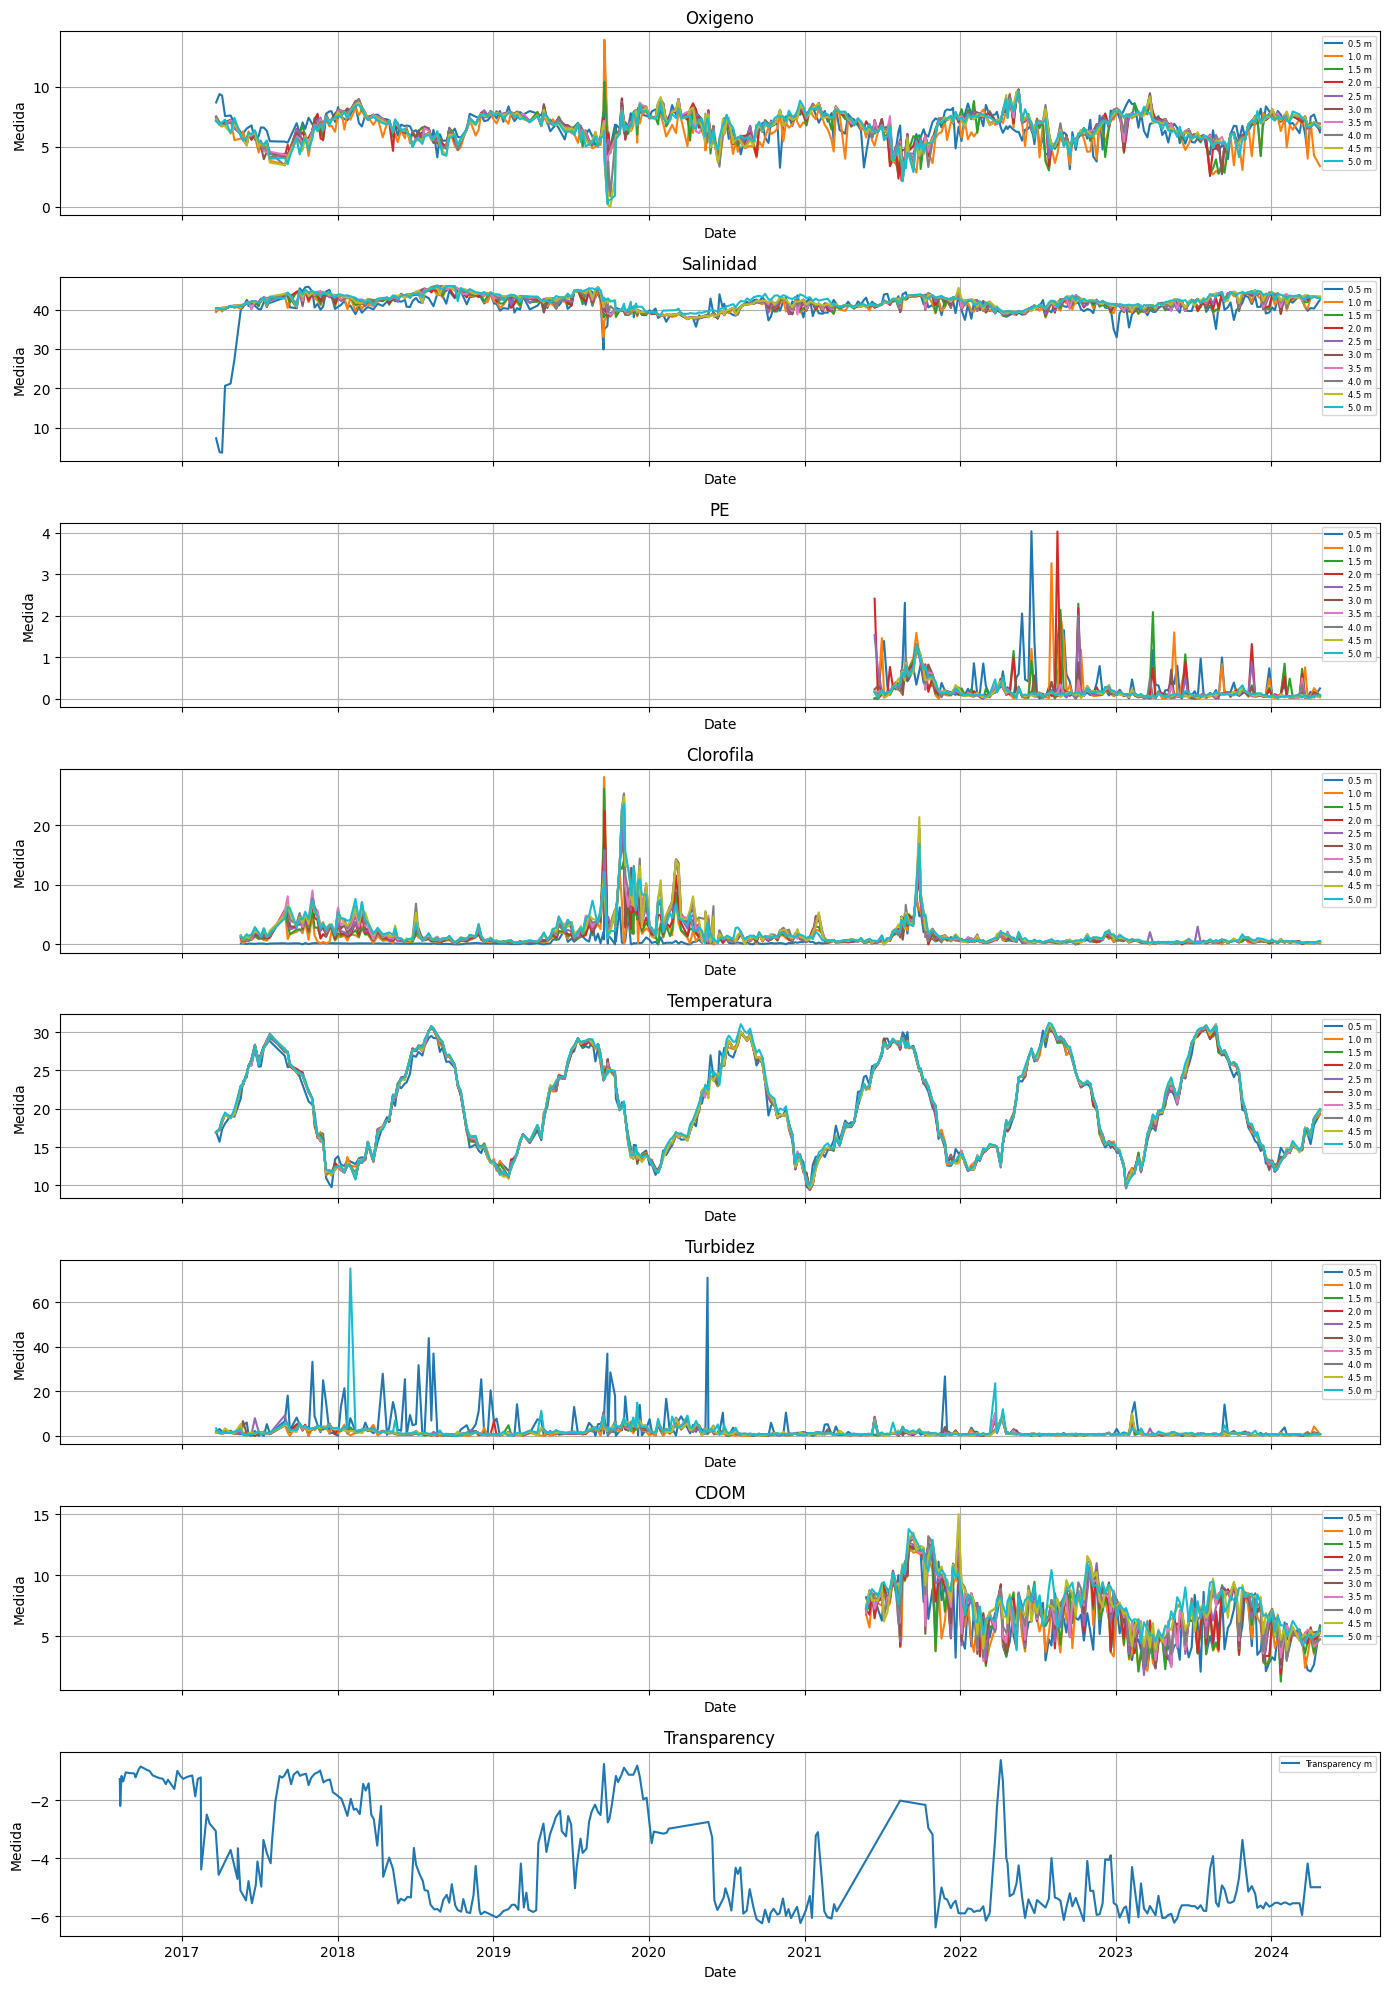

In [266]:
fig, ax = plt.subplots(figsize = (14,len(archivos_csv)*2.5), nrows=len(archivos_csv), ncols=1, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(buoys.items()):
    # Convertir la columna 'Fecha' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    # Graficar cada columna de profundidad
    for columna in df.columns:
        if columna != 'Date':
            ax[i].plot(df['Date'], df[columna], label=f'{columna} m')

    # Configurar el subplot
    ax[i].set_title(nombre)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Medida')
    ax[i].legend(loc='best', fontsize=6)
    ax[i].grid(True)

fig.tight_layout()

Además de dejar una única medida, si se puede, de cada parámetro, guardar también la desviación estándar

#### Planteamiento - ¿Qué queremos hacer con cada paso del procesado?
- Ver si para cada parámetro de cada boya (Oxígeno, Temperatura, etc) es posible quedarnos con una medida representativa de todas las profundidades (+ su desviación estándar)
    - Comprobar normalidad y homogeneidad de varianzas de las series temporales.
    - Comprobar stationarity con ADF
    - Aplicar los tests de series temporales correspondientes: tipo ANOVA para analizar la igualdad de medias o tipo Engle-Granger si las series son no estacionarias
    - Análisis espectral para ver si están compuestas por las mismas frecuencias y análisis de correlación (directa, sin lags, tipo Pearson o Spearman)
- Ver cómo de relacionados están los caudales + relación con nivel y lluvia
    - Cross-correlation con lags y correlación directa
    - Análisis espectral
    - Para hacer este análisis representar un scatter plot de caudal SAIH vs caudal CMM y similares
- Pensar en cómo se puede reconstruir la serie de nitratos con las medidas que hay del SAIH
    - Encontrar alguna (s) variable que guarde algún tipo de correlación con los nitratos

### Caudal, Nivel y Pluviómetro

In [147]:
df_caudal[["Fecha","Desembocadura rambla Albujón"]].set_index("Fecha")
caudal

,Caudal
Date,
2021-01-12,184.312500
2021-01-13,184.152778
2021-01-14,177.222222
2021-01-15,174.468750
2021-01-16,171.753472
...,...
2024-05-22,73.699306
2024-05-23,78.806250
2024-05-24,86.551389


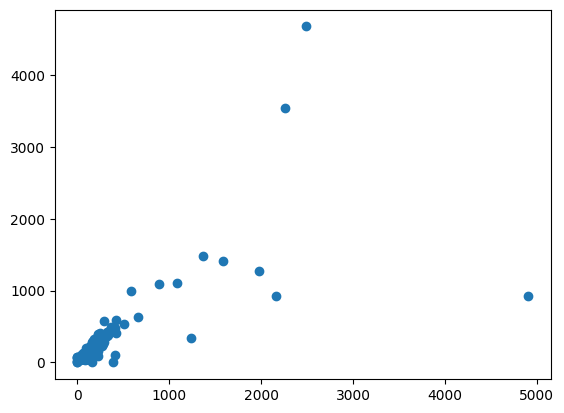

In [173]:
# Caudal vs caudal

merge_caudal = pd.concat([df_caudal[["Fecha","Desembocadura rambla Albujón"]].set_index("Fecha"), caudal], axis=1).dropna()

plt.scatter(merge_caudal["Caudal"], merge_caudal["Desembocadura rambla Albujón"])
plt.show()

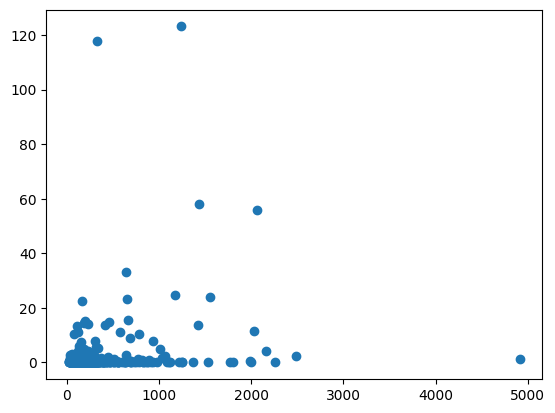

In [177]:
merge_caudal_pluvio = pd.concat([pluviometro, caudal], axis=1).dropna()
# Sumar pluvio de La Puebla y Pozo Estrecho a ver si cambia
plt.scatter(merge_caudal_pluvio["Caudal"], merge_caudal_pluvio["Pluviometro"])
plt.show()

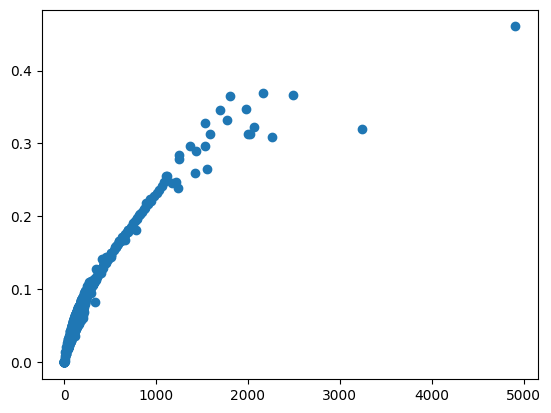

In [178]:
merge_caudal_nivel = pd.concat([nivel, caudal], axis=1).dropna()

plt.scatter(merge_caudal_nivel["Caudal"], merge_caudal_nivel["Nivel"])
plt.show()

Levene's Test Statistic: 44.51273426109891
P-value: 1.2355571817180965e-17
Reject the null hypothesis: The variances are not homogeneous.


Fisher's F Test Statistic: 0.22671356584296692
P-value: 1.6205546755716976e-12
Reject the null hypothesis: The variances are not equal.


Brown-Forsythe Test Statistic: 44.10910563206098
P-value: 1.686053671542278e-17
Reject the null hypothesis: The variances are not homogeneous.


Test Statistic: -3.9953431435565987
P-value: 9.106540086305172e-05
Reject the null hypothesis: The means are not equal.


In [285]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare

np.random.seed(42)
group1 = np.random.normal(20, 6, 10)  # Group 1: Mean 20, std 5
group2 = np.random.normal(25, 5, 10)  # Group 2: Mean 22, std 5
group3 = np.random.normal(15, 6, 10)  # Group 3: Mean 21, std 5

# Stack the groups into a single array
data = np.vstack([group1, group2, group3]).T
df = pd.DataFrame(data, columns=['Group1', 'Group2', 'Group3'])

# Friedman test as an example
stat, p_value = friedmanchisquare(df['Group1'], df['Group2'], df['Group3'])
print(f'Friedman Test Statistic: {stat}')
print(f'P-value: {p_value}')

if p_value < 0.05:  # Only perform post-hoc test if Friedman test is significant
    nemenyi_results = sp.posthoc_nemenyi_friedman(df)
    print(nemenyi_results)
else:
    print("No significant differences found in the Friedman test; skipping Nemenyi test.")


Friedman Test Statistic: 9.599999999999994
P-value: 0.008229747049020053
          Group1    Group2    Group3
Group1  1.000000  0.900000  0.019949
Group2  0.900000  1.000000  0.019949
Group3  0.019949  0.019949  1.000000


In [ ]:
# CCF - con ADF antes para ver si hay stationarity, si no la hay, descartar este test
# Two-Sample por pares de Kolmogorov Smirnov
# Correlación de Spearman? Si no se cumplen las condiciones de linearity, normality y homoscedasticity